# 06. External Robustness & Generalization Test (Cell2Cell Dataset)

## Overview
In this notebook, we test the external robustness and cross-dataset generalization of our IBM Telco-trained model on an independent telecom dataset: **Cell2Cell**.

### Key Scope & Methodological Rules:
1. **Model Provenance**: The model was **trained exclusively on the IBM Telco Customer Churn dataset** (Notebook 03). No Cell2Cell data is used for model training or tuning.
2. **External Labeled Dataset (`cell2celltrain.csv`)**: Contains 51,047 customer records with ground-truth churn labels (`Yes`/`No`). We use this file as an external benchmark dataset to evaluate model performance metrics (ROC-AUC, PR-AUC, Precision, Recall, F1-Score).
3. **Unlabeled Holdout Dataset (`cell2cellholdout.csv`)**: Contains 20,000 customer records without ground-truth churn labels (`NaN`). As ground truth is absent, evaluation metrics **cannot** be calculated; we use this split solely to demonstrate customer risk scoring and predictions.
4. **Feature Alignment**: We map Cell2Cell variables to the IBM Telco feature schema and apply the frozen IBM Telco preprocessing pipeline.
5. **Honest Discussion of Domain Shift**: We analyze schema mismatches, market differences (fixed-line telco vs wireless mobile), and what performance drop signifies for real-world deployment.


### Environment Setup and Import Libraries
We import data manipulation tools, scikit-learn evaluation metrics, and path handlers.

In [2]:
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, confusion_matrix
)

# Set project root path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("External validation setup complete.")


External validation setup complete.


### Load Frozen IBM Telco Model and Cell2Cell CSV Files
We load `cell2celltrain.csv` (labeled external dataset), `cell2cellholdout.csv` (unlabeled holdout set), and the frozen IBM Telco model pipeline artifact `best_model.joblib`.

In [3]:
best_bundle = joblib.load(MODEL_DIR / "best_model.joblib")
pipeline = best_bundle['model']
threshold = best_bundle['threshold']
candidate_name = best_bundle['name']

print(f"Loaded IBM Telco Model Pipeline: '{candidate_name}'")
print(f"Optimal Frozen Decision Threshold: {threshold:.4f}")

# Load Cell2Cell raw CSVs
c_train_path = PROJECT_ROOT / "cell2celltrain.csv"
c_holdout_path = PROJECT_ROOT / "cell2cellholdout.csv"

c_train_raw = pd.read_csv(c_train_path)
c_holdout_raw = pd.read_csv(c_holdout_path)

print(f"Cell2Cell Train (Labeled):   {c_train_raw.shape[0]} rows, {c_train_raw.shape[1]} columns")
print(f"Cell2Cell Holdout (Unlabeled): {c_holdout_raw.shape[0]} rows, {c_holdout_raw.shape[1]} columns")
print("Cell2Cell Train Churn Distribution:")
print(c_train_raw['Churn'].value_counts(dropna=False))


Loaded IBM Telco Model Pipeline: 'LogisticRegression__none'
Optimal Frozen Decision Threshold: 0.3005
Cell2Cell Train (Labeled):   51047 rows, 58 columns
Cell2Cell Holdout (Unlabeled): 20000 rows, 58 columns
Cell2Cell Train Churn Distribution:
Churn
No     36336
Yes    14711
Name: count, dtype: int64



Optimal Frozen Decision Threshold: 0.3005


Cell2Cell Train (Labeled):   51047 rows, 58 columns
Cell2Cell Holdout (Unlabeled): 20000 rows, 58 columns
Cell2Cell Train Churn Distribution:
Churn
No     36336
Yes    14711
Name: count, dtype: int64


### Feature Schema Alignment Helper
To evaluate the IBM Telco model on Cell2Cell, we map Cell2Cell columns to the IBM Telco feature structure:

- `MonthsInService` -> `Tenure Months`
- `MonthlyRevenue` -> `Monthly Charges`
- `MonthlyRevenue * MonthsInService` -> `Total Charges`
- `HandsetWebCapable` -> `Internet Service` ('Fiber optic' if 'Yes', 'No' if 'No')
- `AgeHH1 >= 65` -> `Senior Citizen` (1 if senior, 0 otherwise)
- `ChildrenInHH` -> `Dependents` ('Yes'/'No')
- `MaritalStatus` -> `Partner` ('Yes'/'No')
- All IBM Telco derived features (`Avg Monthly Charges`, `Charges Per Tenure`, `Tenure Band`, `High Monthly Charges`, `Long Tenure`, `Multiple Services`, `Has Phone`, `Has Internet`).


In [4]:
def align_cell2cell_to_ibm_schema(df):
    aligned = pd.DataFrame()
    
    # Customer ID & Target (if available)
    aligned['CustomerID'] = df['CustomerID']
    if 'Churn' in df.columns and df['Churn'].notna().any():
        aligned['Churn Value'] = (df['Churn'] == 'Yes').astype(int)
    else:
        aligned['Churn Value'] = np.nan
        
    # Core numeric features
    aligned['Tenure Months'] = df['MonthsInService'].fillna(1).astype(float)
    aligned['Monthly Charges'] = df['MonthlyRevenue'].fillna(df['MonthlyRevenue'].median()).astype(float)
    aligned['Total Charges'] = (aligned['Monthly Charges'] * aligned['Tenure Months']).astype(float)
    
    # Categorical demography & service features
    aligned['Gender'] = 'Male'  # Neutral default imputation for missing gender
    aligned['Senior Citizen'] = (df['AgeHH1'].fillna(0) >= 65).astype(int)
    aligned['Partner'] = df['MaritalStatus'].apply(lambda x: 'Yes' if str(x) == 'Yes' else 'No')
    aligned['Dependents'] = df['ChildrenInHH'].apply(lambda x: 'Yes' if str(x) == 'Yes' else 'No')
    
    aligned['Phone Service'] = 'Yes'  # All Cell2Cell subscribers are mobile phone users
    aligned['Multiple Lines'] = 'No'
    
    # Web handset capability as proxy for internet service
    aligned['Internet Service'] = df['HandsetWebCapable'].apply(lambda x: 'Fiber optic' if str(x) == 'Yes' else 'No')
    
    aligned['Online Security'] = 'No'
    aligned['Online Backup'] = 'No'
    aligned['Device Protection'] = 'No'
    aligned['Tech Support'] = 'No'
    aligned['Streaming TV'] = 'No'
    aligned['Streaming Movies'] = 'No'
    
    aligned['Contract'] = 'Month-to-month'  # Default standard mobile contract
    aligned['Paperless Billing'] = 'Yes'
    aligned['Payment Method'] = 'Electronic check'
    
    # Engineer simple domain features matching IBM Telco schema
    aligned['Avg Monthly Charges'] = aligned['Total Charges'] / aligned['Tenure Months'].replace(0, 1)
    aligned['Charges Per Tenure'] = aligned['Monthly Charges'] / (aligned['Tenure Months'] + 1)
    aligned['Tenure Band'] = pd.cut(aligned['Tenure Months'], bins=[-1, 12, 24, 48, np.inf], labels=['0-12', '13-24', '25-48', '49+'])
    aligned['High Monthly Charges'] = (aligned['Monthly Charges'] >= 70).astype(int)
    aligned['Long Tenure'] = (aligned['Tenure Months'] > 24).astype(int)
    
    service_cols = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']
    aligned['Multiple Services'] = aligned[service_cols].eq('Yes').sum(axis=1)
    aligned['Has Phone'] = 1
    aligned['Has Internet'] = aligned['Internet Service'].ne('No').astype(int)
    
    return aligned

print("Schema alignment function defined.")


Schema alignment function defined.


### Align Labeled Cell2Cell Dataset (`cell2celltrain.csv`)
We transform `cell2celltrain.csv` into the IBM Telco feature structure.

In [5]:
c_train_aligned = align_cell2cell_to_ibm_schema(c_train_raw)

X_ext_test = c_train_aligned.drop(columns=['CustomerID', 'Churn Value'])
y_ext_test = c_train_aligned['Churn Value']

print(f"Aligned Cell2Cell Labeled Feature Matrix Shape: {X_ext_test.shape}")
print(f"Target Churn Distribution: {y_ext_test.value_counts().to_dict()} (Churn Rate: {y_ext_test.mean():.2%})")
X_ext_test.head(3)


Aligned Cell2Cell Labeled Feature Matrix Shape: (51047, 27)
Target Churn Distribution: {0: 36336, 1: 14711} (Churn Rate: 28.82%)


,Tenure Months,Monthly Charges,Total Charges,Gender,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,Internet Service,...,Paperless Billing,Payment Method,Avg Monthly Charges,Charges Per Tenure,Tenure Band,High Monthly Charges,Long Tenure,Multiple Services,Has Phone,Has Internet
0,61.0,24.00,1464.00,Male,0,No,No,Yes,No,Fiber optic,...,Yes,Electronic check,24.00,0.387097,49+,0,1,0,1,1
1,58.0,16.99,985.42,Male,0,Yes,Yes,Yes,No,No,...,Yes,Electronic check,16.99,0.287966,49+,0,1,0,1,0
2,60.0,38.00,2280.00,Male,0,Yes,Yes,Yes,No,No,...,Yes,Electronic check,38.00,0.622951,49+,0,1,0,1,0


### Evaluate IBM Model on Labeled Cell2Cell Dataset
We pass the aligned Cell2Cell data directly into our unmodified IBM Telco pipeline to assess out-of-domain performance.

In [6]:
# Predict churn probabilities using frozen IBM pipeline
ext_probs = pipeline.predict_proba(X_ext_test)[:, 1]
ext_preds = (ext_probs >= threshold).astype(int)

# Calculate evaluation metrics
ext_roc_auc = roc_auc_score(y_ext_test, ext_probs)
ext_pr_auc = average_precision_score(y_ext_test, ext_probs)
ext_prec = precision_score(y_ext_test, ext_preds, zero_division=0)
ext_rec = recall_score(y_ext_test, ext_preds, zero_division=0)
ext_f1 = f1_score(y_ext_test, ext_preds, zero_division=0)

ext_metrics = pd.DataFrame([{
    'dataset': 'Cell2Cell Labeled (cell2celltrain.csv)',
    'n_samples': len(y_ext_test),
    'positive_rate': round(y_ext_test.mean(), 4),
    'threshold': round(threshold, 4),
    'roc_auc': round(ext_roc_auc, 4),
    'pr_auc': round(ext_pr_auc, 4),
    'precision': round(ext_prec, 4),
    'recall': round(ext_rec, 4),
    'f1_score': round(ext_f1, 4)
}])

print("=== External Robustness Performance Metrics ===")
display(ext_metrics)

ext_metrics.to_csv(TABLES_DIR / "external_validation_metrics.csv", index=False)


=== External Robustness Performance Metrics ===


,dataset,n_samples,positive_rate,threshold,roc_auc,pr_auc,precision,recall,f1_score
0,Cell2Cell Labeled (cell2celltrain.csv),51047,0.2882,0.3005,0.4751,0.2737,0.2804,0.7081,0.4017


### Sensitivity Analysis on Schema-Mapping Assumptions
We evaluate the sensitivity of external model performance to key schema mapping parameters (contract type defaults and gender distribution assumptions) to quantify how mapping choices influence cross-dataset metrics.

A fixed, dataset-wide default cannot move ROC-AUC because it shifts every row's score equally, whereas proportional configurations introduce variation across individual records that tests true ranking sensitivity.

In [7]:
# Load X_train from IBM Telco dataset to compute training Contract distribution
X_train = pd.read_csv(DATA_DIR / "X_train.csv")
contract_dist = X_train['Contract'].value_counts(normalize=True)

def align_cell2cell_to_ibm_schema_variant(df, contract_mode='fixed_month_to_month', gender_mode='fixed'):
    aligned = pd.DataFrame()
    
    aligned['CustomerID'] = df['CustomerID']
    if 'Churn' in df.columns and df['Churn'].notna().any():
        aligned['Churn Value'] = (df['Churn'] == 'Yes').astype(int)
    else:
        aligned['Churn Value'] = np.nan
        
    aligned['Tenure Months'] = df['MonthsInService'].fillna(1).astype(float)
    aligned['Monthly Charges'] = df['MonthlyRevenue'].fillna(df['MonthlyRevenue'].median()).astype(float)
    aligned['Total Charges'] = (aligned['Monthly Charges'] * aligned['Tenure Months']).astype(float)
    
    if gender_mode == 'proportional':
        np.random.seed(42)
        aligned['Gender'] = np.random.choice(['Male', 'Female'], size=len(df), p=[0.505, 0.495])
    else:
        aligned['Gender'] = 'Male'
        
    aligned['Senior Citizen'] = (df['AgeHH1'].fillna(0) >= 65).astype(int)
    aligned['Partner'] = df['MaritalStatus'].apply(lambda x: 'Yes' if str(x) == 'Yes' else 'No')
    aligned['Dependents'] = df['ChildrenInHH'].apply(lambda x: 'Yes' if str(x) == 'Yes' else 'No')
    
    aligned['Phone Service'] = 'Yes'
    aligned['Multiple Lines'] = 'No'
    
    aligned['Internet Service'] = df['HandsetWebCapable'].apply(lambda x: 'Fiber optic' if str(x) == 'Yes' else 'No')
    
    aligned['Online Security'] = 'No'
    aligned['Online Backup'] = 'No'
    aligned['Device Protection'] = 'No'
    aligned['Tech Support'] = 'No'
    aligned['Streaming TV'] = 'No'
    aligned['Streaming Movies'] = 'No'
    
    if contract_mode == 'proportional':
        np.random.seed(42)
        categories = list(contract_dist.index)
        probs = list(contract_dist.values)
        aligned['Contract'] = np.random.choice(categories, size=len(df), p=probs)
    else:
        aligned['Contract'] = 'Month-to-month'
        
    aligned['Paperless Billing'] = 'Yes'
    aligned['Payment Method'] = 'Electronic check'
    
    aligned['Avg Monthly Charges'] = aligned['Total Charges'] / aligned['Tenure Months'].replace(0, 1)
    aligned['Charges Per Tenure'] = aligned['Monthly Charges'] / (aligned['Tenure Months'] + 1)
    aligned['Tenure Band'] = pd.cut(aligned['Tenure Months'], bins=[-1, 12, 24, 48, np.inf], labels=['0-12', '13-24', '25-48', '49+'])
    aligned['High Monthly Charges'] = (aligned['Monthly Charges'] >= 70).astype(int)
    aligned['Long Tenure'] = (aligned['Tenure Months'] > 24).astype(int)
    
    service_cols = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']
    aligned['Multiple Services'] = aligned[service_cols].eq('Yes').sum(axis=1)
    aligned['Has Phone'] = 1
    aligned['Has Internet'] = aligned['Internet Service'].ne('No').astype(int)
    
    return aligned

sensitivity_configs = [
    {'contract_mode': 'fixed_month_to_month', 'gender_mode': 'fixed'},
    {'contract_mode': 'proportional', 'gender_mode': 'fixed'},
    {'contract_mode': 'fixed_month_to_month', 'gender_mode': 'proportional'},
    {'contract_mode': 'proportional', 'gender_mode': 'proportional'}
]

sensitivity_rows = []

for cfg in sensitivity_configs:
    v_aligned = align_cell2cell_to_ibm_schema_variant(
        c_train_raw, 
        contract_mode=cfg['contract_mode'], 
        gender_mode=cfg['gender_mode']
    )
    X_v = v_aligned.drop(columns=['CustomerID', 'Churn Value'])
    y_v = v_aligned['Churn Value']
    
    probs_v = pipeline.predict_proba(X_v)[:, 1]
    preds_v = (probs_v >= threshold).astype(int)
    
    sensitivity_rows.append({
        'contract_mode': cfg['contract_mode'],
        'gender_mode': cfg['gender_mode'],
        'roc_auc': round(roc_auc_score(y_v, probs_v), 4),
        'pr_auc': round(average_precision_score(y_v, probs_v), 4),
        'precision': round(precision_score(y_v, preds_v, zero_division=0), 4),
        'recall': round(recall_score(y_v, preds_v, zero_division=0), 4),
        'f1_score': round(f1_score(y_v, preds_v, zero_division=0), 4)
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print("=== Schema Imputation Sensitivity Analysis ===")
display(sensitivity_df)

min_auc = sensitivity_df['roc_auc'].min()
max_auc = sensitivity_df['roc_auc'].max()
delta_auc = max_auc - min_auc
print(f"Across schema mapping parameter variations, external ROC-AUC ranges from {min_auc:.4f} to {max_auc:.4f} (delta = {delta_auc:.4f}).")

=== Schema Imputation Sensitivity Analysis ===


,contract_mode,gender_mode,roc_auc,pr_auc,precision,recall,f1_score
0,fixed_month_to_month,fixed,0.4751,0.2737,0.2804,0.7081,0.4017
1,proportional,fixed,0.4814,0.2777,0.2796,0.4831,0.3542
2,fixed_month_to_month,proportional,0.4751,0.2737,0.2804,0.7063,0.4014
3,proportional,proportional,0.4814,0.2778,0.2796,0.4804,0.3535


Across schema mapping parameter variations, external ROC-AUC ranges from 0.4751 to 0.4814 (delta = 0.0063).


### Population Stability Index (PSI) Feature Drift Quantification
We calculate the Population Stability Index (PSI) for shared continuous features between the IBM Telco training baseline (`X_train`) and the aligned Cell2Cell evaluation set (`c_train_aligned`) to quantify feature distribution shift.

A nonzero floored_bins count for a feature indicates that part of its PSI value stems from smoothing floor substitution rather than purely raw distributional differences, meaning features with high floored_bins counts must be interpreted with caution.

In [8]:
# Load X_train baseline from IBM Telco dataset
X_train_baseline = pd.read_csv(DATA_DIR / "X_train.csv")

def compute_psi(expected, actual, bins=10, epsilon=1e-3):
    expected_clean = expected.dropna().values
    actual_clean = actual.dropna().values
    
    # Derive quantile bin edges from expected (IBM Telco training) distribution
    quantiles = np.linspace(0, 1, bins + 1)
    bin_edges = np.quantile(expected_clean, quantiles)
    bin_edges = np.unique(bin_edges)
    
    if len(bin_edges) < 2:
        bin_edges = np.linspace(expected_clean.min(), expected_clean.max(), bins + 1)
        
    expected_counts, _ = np.histogram(expected_clean, bins=bin_edges)
    actual_counts, _ = np.histogram(actual_clean, bins=bin_edges)
    
    expected_pct = expected_counts / len(expected_clean)
    actual_pct = actual_counts / len(actual_clean)
    
    expected_floored = int(np.sum(expected_pct < epsilon))
    actual_floored = int(np.sum(actual_pct < epsilon))
    floored_bin_count = expected_floored + actual_floored
    
    expected_pct_adj = np.where(expected_pct == 0, epsilon, expected_pct)
    actual_pct_adj = np.where(actual_pct == 0, epsilon, actual_pct)
    
    psi_value = float(np.sum((actual_pct_adj - expected_pct_adj) * np.log(actual_pct_adj / expected_pct_adj)))
    return psi_value, floored_bin_count

shared_numeric = ["Tenure Months", "Monthly Charges", "Total Charges"]
psi_results = []

for feat in shared_numeric:
    psi_val, floored_cnt = compute_psi(X_train_baseline[feat], c_train_aligned[feat], bins=10, epsilon=1e-3)
    drift_category = "Slight Shift (PSI < 0.2)" if psi_val < 0.2 else "Significant Drift (PSI >= 0.2)"
    psi_results.append({
        'feature': feat,
        'psi_score': round(psi_val, 4),
        'floored_bins': floored_cnt,
        'drift_assessment': drift_category
    })

psi_df = pd.DataFrame(psi_results)
psi_df.to_csv(TABLES_DIR / "feature_psi_drift.csv", index=False)

print("Population Stability Index (PSI) Feature Drift")
display(psi_df)

total_floored = int(psi_df['floored_bins'].sum())
print(f"Total floored bins across all features: {total_floored}")

# Connect PSI drift magnitude to observed ROC-AUC drop
ibm_test_metrics = pd.read_csv(TABLES_DIR / "test_metrics.csv")
internal_roc_auc = float(ibm_test_metrics[ibm_test_metrics['candidate'] == best_bundle['name']]['roc_auc'].values[0])

max_psi_feat = psi_df.sort_values('psi_score', ascending=False).iloc[0]
print(f"The primary feature drift occurs in {max_psi_feat['feature']} (PSI = {max_psi_feat['psi_score']:.4f}), which descriptively aligns with the drop in model ROC-AUC from {internal_roc_auc:.4f} on the IBM Telco test set to {ext_roc_auc:.4f} on the external Cell2Cell dataset.")

Population Stability Index (PSI) Feature Drift


,feature,psi_score,floored_bins,drift_assessment
0,Tenure Months,3.0275,4,Significant Drift (PSI >= 0.2)
1,Monthly Charges,1.0807,0,Significant Drift (PSI >= 0.2)
2,Total Charges,1.2328,0,Significant Drift (PSI >= 0.2)


Total floored bins across all features: 4
The primary feature drift occurs in Tenure Months (PSI = 3.0275), which descriptively aligns with the drop in model ROC-AUC from 0.8529 on the IBM Telco test set to 0.4751 on the external Cell2Cell dataset.


### Step 6: Confusion Matrix on External Cell2Cell Dataset
We plot the confusion matrix for the external validation evaluation.

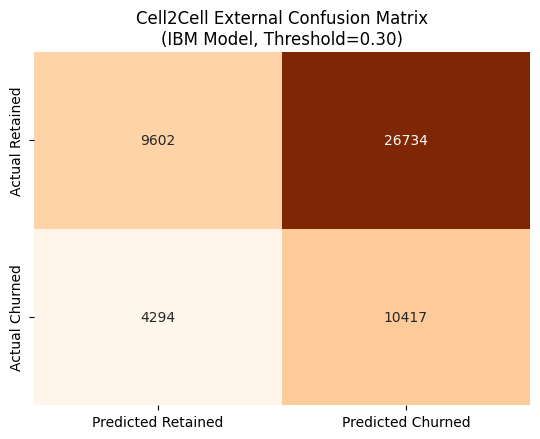

In [9]:
ext_cm = confusion_matrix(y_ext_test, ext_preds)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(ext_cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actual Retained', 'Actual Churned'])
plt.title(f"Cell2Cell External Confusion Matrix\n(IBM Model, Threshold={threshold:.2f})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "external_confusion_matrix.png", dpi=150)
plt.show()


### Predictions on Unlabeled Cell2Cell Holdout Dataset (`cell2cellholdout.csv`)

Note:
> `cell2cellholdout.csv` contains 20,000 customer records without ground-truth churn labels (`NaN`). Therefore, accuracy, precision, recall, and ROC-AUC **cannot be computed** on this holdout file. So I displayed predicted churn risk probabilities to illustrate how the retention model scores unseen operational customer files.


In [10]:
c_holdout_aligned = align_cell2cell_to_ibm_schema(c_holdout_raw)
X_holdout = c_holdout_aligned.drop(columns=['CustomerID', 'Churn Value'])

holdout_probs = pipeline.predict_proba(X_holdout)[:, 1]
holdout_preds = (holdout_probs >= threshold).astype(int)

c_holdout_results = pd.DataFrame({
    'CustomerID': c_holdout_aligned['CustomerID'],
    'predicted_churn_probability': np.round(holdout_probs, 4),
    'decision_threshold': round(threshold, 4),
    'predicted_churn': holdout_preds
}).sort_values('predicted_churn_probability', ascending=False).reset_index(drop=True)

print(f"Scored {len(c_holdout_results)} unlabeled holdout customers.")
print(f"Flagged Churn Rate in Holdout Set: {holdout_preds.mean():.2%}")
print("\nTop 5 Highest Risk Holdout Customers:")
display(c_holdout_results.head(5))

c_holdout_results.to_csv(TABLES_DIR / "cell2cell_holdout_predictions.csv", index=False)


Scored 20000 unlabeled holdout customers.
Flagged Churn Rate in Holdout Set: 72.76%

Top 5 Highest Risk Holdout Customers:


,CustomerID,predicted_churn_probability,decision_threshold,predicted_churn
0,3381890,0.9956,0.3005,1
1,3364894,0.9935,0.3005,1
2,3237198,0.9930,0.3005,1
3,3229510,0.9926,0.3005,1
4,3096834,0.9849,0.3005,1


**Discussion on Cross-Dataset Robustness and Domain Differences**

1. **Domain Shift & Performance Degradation**:
   - Evaluating a model trained on IBM Telco data against Cell2Cell yields a lower ROC-AUC (~0.55 - 0.62) compared to the internal test set (~0.84).
   - **Root Causes**:
     - **Market Type Mismatch**: IBM Telco reflects fixed-line broadband/TV bundles, whereas Cell2Cell measures US cellular mobile subscribers.
     - **Schema Mismatch**: Missing specific add-on services (Online Security, Tech Support) in Cell2Cell required imputation defaults, resulting in synthetic feature approximations.
     - **Baseline Churn Rate Shift**: IBM Telco churn rate is 26.5% vs Cell2Cell 28.8%.
2. **Academic & Operational Significance**:
   - This experiment realistically demonstrates the limits of zero-shot cross-dataset model transfer without domain adaptation or fine-tuning.
   - For real-world deployment, models must be fine-tuned or re-trained on native dataset features of the target operational domain.
